In [1]:
from torch import nn as nn
import torch
import torch.autograd as ag
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def differential_equation(t:torch.Tensor):
    r: float = 1.0
    return r*t*(1-t)

def solution(x):
    return (-1/3)*x**3 + (1/2)*x**2 + 1

In [3]:
#Building Neural Network Model
#base class for all neural network modules
class PINNModel(nn.Module):
    #constructor that takes in the parameters for the model
    def __init__(self, input_size: int = 1, output_size: int = 1, hidden_layers: int = 5, hidden_nodes: int = 10):
        super().__init__()
        #connecting the layers using nn.Linear(input,output)
        self.inputs = nn.Linear(input_size, hidden_nodes)
        self.model = nn.ModuleList([nn.Linear(hidden_nodes, hidden_nodes) for _ in range(hidden_layers)]) #creates list of these layers to iterate through
        self.outputs = nn.Linear(hidden_nodes, output_size)

        self.activation = nn.Tanh() # makes it nonlinear

    #applies activation to all layers in the model
    def _apply_model(self,x: torch.Tensor):
        for layer in self.model:
            x = self.activation(layer(x))
        return x

    #This is the prediction function
    def forward(self, t: torch.Tensor):
        t = self.activation(self.inputs(t))
        t = self._apply_model(t)
        t = self.outputs(t)
        return t


In [4]:
#Preparing Points for Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = torch.linspace(0, 1, 100).reshape(-1, 1) #many data points
y = solution(x).reshape(-1, 1) #analytical solution for the differential equation

#take only certain points for training
x_data = x[0:200:20]
y_data = y[0:200:20]

#move tensors to the selected device
x_data_t = x_data.detach().clone().to(device=device, dtype=torch.float32).reshape(-1, 1)
y_data_t = y_data.detach().clone().to(device=device, dtype=torch.float32).reshape(-1, 1)

#creating points for physics loss
x_physics = torch.linspace(0, 1, 100, requires_grad=True, device=device, dtype=torch.float32).reshape(-1, 1)

In [15]:
#Training Loop
#Goals: Match the data points and satisfy the differential equation
Epochs = 20000
Length = 1e4

model = PINNModel().to(device) #create neural network
optimize = torch.optim.Adam(model.parameters(), lr=1e-3) #optimizer for the model parameters

data_loss = nn.MSELoss()

#for loop that trains the model
for epoch in range(Epochs):
    optimize.zero_grad() #reset the gradient to 0 at the start of each loop
    
    #data loss
    y_pred = model(x_data_t) #generates prediction
    loss_data = data_loss(y_pred, y_data_t) #compares prediction to the data points and calculates the loss

    #physics loss
    y_physics = model(x_physics) #generates prediction for physics points
    dy_physics = ag.grad(y_physics, x_physics, torch.ones_like(y_physics), create_graph=True)[0] #calculates derivative
    physics = dy_physics - differential_equation(x_physics) #calculates physics loss
    loss_physics = torch.mean(physics**2) #calculates mean squared error for physics loss
    total_loss = loss_data + loss_physics

    total_loss.backward() #figures out what weights caused the error
    optimize.step() #fixes the model slightly to minimize error
    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}, Total Loss: {total_loss.item()}, Data Loss: {loss_data.item()}, Physics Loss: {loss_physics.item()}")

Epoch: 0, Total Loss: 0.8963373303413391, Data Loss: 0.8652639389038086, Physics Loss: 0.031073367223143578
Epoch: 1000, Total Loss: 0.00020720777683891356, Data Loss: 6.540632284668391e-07, Physics Loss: 0.00020655371190514416
Epoch: 2000, Total Loss: 8.527092722943053e-05, Data Loss: 2.537421437409648e-07, Physics Loss: 8.50171854835935e-05
Epoch: 3000, Total Loss: 2.7036223855247954e-06, Data Loss: 4.406135012402501e-09, Physics Loss: 2.6992163384420564e-06
Epoch: 4000, Total Loss: 1.4826802043899079e-06, Data Loss: 4.81223594306357e-09, Physics Loss: 1.4778679542359896e-06
Epoch: 5000, Total Loss: 1.1092761269537732e-06, Data Loss: 4.043252399554831e-09, Physics Loss: 1.105232854570204e-06
Epoch: 6000, Total Loss: 1.721248395369912e-06, Data Loss: 5.008664629713167e-07, Physics Loss: 1.2203819323985954e-06
Epoch: 7000, Total Loss: 5.826971687383775e-07, Data Loss: 3.87609011553991e-09, Physics Loss: 5.788210728496779e-07
Epoch: 8000, Total Loss: 4.2145151724071184e-07, Data Loss: 1

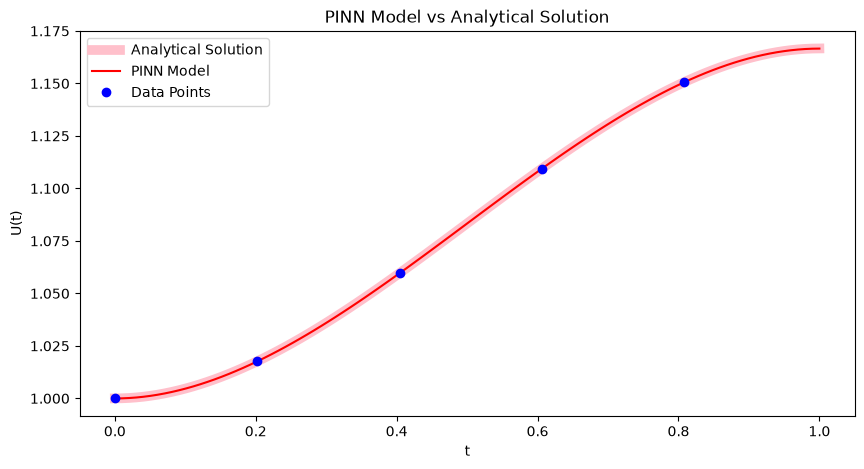

In [16]:
#Testing the Model
model.eval()
x_test = x.detach().clone().to(device=device, dtype=torch.float32)
y_pred = model(x_test).detach().cpu().numpy().reshape(-1, 1) #get Pinn Solution curve

#Plotting the Neural Network Model vs Analytical Solution
plt.figure(figsize=(10, 5))
plt.title("PINN Model vs Analytical Solution")
plt.plot(x, y, label="Analytical Solution", color="pink", linewidth=7)
plt.xlabel("t")
plt.ylabel("U(t)")

#plotting the analytical solution
plt.plot(x, y_pred, label="PINN Model", color="red")

#plotting the training data points
plt.plot(x_data, y_data, label="Data Points", color="blue", linestyle="None", marker="o")
plt.legend()
plt.show()